# Table of contents

* **Introduction**
* **Objective**
* **Pipeline Overview**
* **Data Dictionary**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
    * Text Cleaning and Normalization
    * Advanced Linguistic Processing (Lemmatization and POS Tagging)
    * Text Representation (CountVectorizer and Gensim Conversion)
    * Tokenization
* **Model Training**
    * Latent Dirichlet Allocation (LDA) Model Training and Visualization
    * Hyperparameter Optimization (Number of Topics Experiment)
    * Final Model Training with Optimized Hyperparameters
* **Model Evaluation**
    * Topics Coherence Score Evaluation
    * Topic Clusters Visualization (Test Dataset)
* **Conclusion**
* **References**

# Introduction

Research papers are being published at an ever-increasing rate, which makes it difficult for researchers to quickly grasp the main themes across thousands of documents. Topic modeling is an unsupervised machine learning technique that automatically discovers hidden thematic structures in a large text corpus.

This tutorial demonstrates a complete, end-to-end pipeline for Latent Dirichlet Allocation (LDA) using a dataset of arXiv scientific paper abstracts (approximately 68k documents). The overall goal is to discover the dominant research themes in the corpus.

Visual analysis of the dataset shows the distribution of articles across the categories (e.g., sport, business, entertainment, politics, tech), which appear to be relatively balanced before sampling.

# Objective

The primary objective is to discover the dominant research themes in the arXiv abstracts and identify the optimal number of topics using a quantitative coherence metric known as $C_V$.The success criteria for this project are defined as follows:

- The $C_V$ coherence metric on the training set should be approximately $0.42$.
- The $C_V$ coherence metric on the test set should be greater than $0.35$.
- The final topics must be clear and human-interpretable, meaning the Top-10 words per topic should make sense together.

# Pipeline Overview

The project follows a sequential process, ensuring data is properly prepared and the model is robustly trained and evaluated. The steps involved in the pipeline are:

- Start with the Raw CSV of the dataset.
- Split the data into Train and Test sets using an $80/20$ ratio.
- Apply Text Cleaning.
- Perform Lemmatization and Part-of-Speech (POS) filtering.
- Use a CountVectorizer to create a Document-Term Matrix.
- Convert the matrix into a Gensim Dictionary and Corpus format.
- Train the initial LDA Model using Gensim.
- Perform Coherence-based Hyper-parameter Tuning.
- Finalize the Model with the optimal number of topics (found to be 8 topics).
- Perform Evaluation on the Test Set.
- Visualize the results using UMAP and t-SNE.

# Data Dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Field Name</th>
    <th class="tg-7zrl">Data Type</th>
    <th class="tg-7zrl">Description</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">id</td>
    <td class="tg-7zrl">string / unique identifier</td>
    <td class="tg-0lax">A unique identifier for each research paper.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">title</td>
    <td class="tg-7zrl">string</td>
    <td class="tg-0lax">The title of the research paper.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">category</td>
    <td class="tg-7zrl">string</td>
    <td class="tg-0lax">The arXiv category to which the paper is classified, such as 'Machine Learning' or 'Artificial Intelligence'.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">category_code</td>
    <td class="tg-7zrl">string</td>
    <td class="tg-0lax">The coded representation for the category of the paper, e.g., 'cs.LG' for Machine Learning and 'cs.AI' for Artificial Intelligence.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">published_date</td>
    <td class="tg-7zrl">date / string</td>
    <td class="tg-0lax">The publication date of the research paper.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">updated_date</td>
    <td class="tg-7zrl">date / string</td>
    <td class="tg-0lax">The last updated date for the paper.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">authors</td>
    <td class="tg-7zrl">string (list)</td>
    <td class="tg-0lax">A list of all authors who contributed to the research paper.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">first_author</td>
    <td class="tg-7zrl">string</td>
    <td class="tg-0lax">The first author mentioned in the paper's author list.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">summary</td>
    <td class="tg-7zrl">string</td>
    <td class="tg-0lax">A summary or abstract of the research paper.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">summary_word_count</td>
    <td class="tg-7zrl">integer</td>
    <td class="tg-0lax">The word count of the paper's summary.</td>
  </tr>
</tbody></table>

**[Dataset Link](https://www.kaggle.com/datasets/sumitm004/arxiv-scientific-research-papers-dataset)**

# Approach

**Pre-processing Pipeline Approach and Concepts**

The pre-processing pipeline is the most critical stage for an LDA model, as the quality of the resulting topics is highly dependent on the quality of the input tokens. The goal is to maximize the Signal-to-Noise Ratio (SNR) by removing common, non-informative words while retaining words that are unique and specific to a theme. Core Techniques and Rationale:

**Normalization and Noise Reduction:**
- Contraction Expansion: Before any tokenization, contractions (e.g., "don't" to "do not") are expanded. This ensures consistent vocabulary representation.
- Lower-casing: Normalizes the case of all text to treat words identically regardless of capitalization.
- Punctuation and Digit Removal: Punctuation and numerical digits are removed using regular expressions. These elements do not contribute to thematic discovery and are considered noise.

**Lexical Simplification and Filtering:**

- Stop-word Removal (NLTK): High-frequency, generic words (like "the," "is," "and") are discarded, as they appear in almost every document and dilute the distinctiveness of topics.
- Lemmatisation (spaCy): This process reduces inflectional forms of a word to a common base root (lemma). For example, "running," "ran," and "runs" all map to "run." This is essential for ensuring that the model groups semantically similar words together, increasing the robustness of the word-topic distribution.

**Semantic Filtering (Part-of-Speech Filtering):**

This is the most powerful filtering step for topic modeling. Tokens are filtered to retain only words belonging to specific Parts-of-Speech (POS) categories: NOUN, PROPN (Proper Noun), ADJ (Adjective), and VERB. Content-Bearing Tokens. By excluding functional words (like adverbs, conjunctions, and prepositions), we ensure that the vocabulary consists primarily of content-bearing tokens—the keywords that define the subject matter of the abstract. This step dramatically improves the final Topic Coherence.

**Model Training Approach and Concepts**

The model training phase involves transforming the cleaned text into a format LDA can process and then fitting the model to the data.

**Latent Dirichlet Allocation (LDA)**

LDA is a probabilistic generative model. It assumes that:
- Every document is a mixture of latent (hidden) topics.
- Every topic is a distribution over words.

The training process involves an iterative estimation (often via Gibbs sampling or variational inference) to discover these underlying word-topic and document-topic distributions.

**Training Pipeline**

- Vectorisation (CountVectorizer): The tokenized documents are converted into a sparse Document-Term Matrix (DTM). This matrix represents the frequency of each word within each document. Sparsity is key for computational efficiency with large corpora.
- Gensim Conversion: The DTM is converted into the specific Gensim format:
- Dictionary: A mapping of every unique word (token) to a unique integer ID.
- Corpus (doc2bow): Each document is converted into a bag-of-words (BoW) format, represented as a list of (token ID, count) tuples. This is the input structure required by the Gensim LDA implementation.
- LDA Model Training (Gensim): The LdaModel is instantiated and fit to the corpus.
- passes Parameter: This controls the number of iterations over the entire corpus. Setting a sufficient number of passes (e.g., 10) is necessary to ensure the model converges and the topic distributions stabilize.
- Reproducibility: A fixed random_state is used to ensure that the results are reproducible across different runs.

**Model Evaluation Approach and Concepts**

Model evaluation for topic modeling must assess two factors: internal consistency (coherence) and generalization (test set performance).

**Primary Metric: Topic Coherence ($C_V$)**

Topic coherence is the most robust measure for evaluating the human interpretability of topics. Coherence measures the degree of semantic similarity between high-scoring words in a single topic. If the top words of a topic co-occur frequently in the source documents, the topic is judged to be more coherent and, therefore, more understandable.

- $C_V$ Coherence: This specific variant of coherence is calculated using a sliding window over the top words, leveraging a normalized point-wise mutual information (NPMI) and a cosine similarity measure based on word embeddings (though $C_V$ primarily uses a data-driven approach to measure semantic relatedness).
- Hyperparameter Tuning: The $C_V$ score is used to sweep a range of potential topic counts, $K$ (e.g., $K \in \{2,\dots,9\}$). The optimal $K$ is selected at the peak $C_V$ score, balancing topic separation with interpretability.

**Hold-out Test Evaluation (Generalization Check)**

The LDA model trained on the optimum $K$ is applied to the previously unseen Test Dataset. The $C_V$ score is calculated on the test corpus. If the test score remains high (relative to the training score), it demonstrates that the discovered topic structure is not over-fitted to the training data and can generalize to new, unseen abstracts.

**Qualitative Check and Visualisation**

- Qualitative Check: The top $N$ words (e.g., 5 or 10) for each final topic are manually inspected to ensure they are semantically related and form a clear, understandable research theme.
- Visualisation (UMAP / t-SNE): Dimensionality reduction techniques like UMAP (Uniform Manifold Approximation and Projection) and t-SNE (t-distributed Stochastic Neighbor Embedding) are used to project the high-dimensional document-topic distributions into a 2D or 3D space. This allows for visual confirmation that documents assigned to the same topic form distinct clusters, validating the model's ability to separate themes geometrically.

# Setup Environments

**Packages Installation**

In [ ]:
%%capture
! pip install contractions

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import contractions
import nltk
from nltk.corpus import stopwords
import spacy
from tqdm import tqdm
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, NMF, LatentDirichletAllocation
from sklearn.manifold import TSNE
import umap
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from gensim.matutils import Sparse2Corpus
from gensim.models.coherencemodel import CoherenceModel
from wordcloud import WordCloud

try:
    stopwords_list = stopwords.words('english')
except nltk.downloader.DownloadError:
    print("Downloading 'stopwords' from NLTK. This will only run once.")
    nltk.download('stopwords')
    stopwords_list = stopwords.words('english')

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Downloading 'en_core_web_sm' from spaCy. This will only run once.")
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

tqdm.pandas()

2025-11-07 15:46:41.581650: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762530401.936578      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762530402.042234      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Data Loading

The initial steps prioritize efficiency and relevance to prepare the massive arXiv dataset for analysis. The process begins by loading the complete dataset. Since the full corpus is large (around 68,000 documents), a random sample of $5%$ is taken. This is a pragmatic decision for a tutorial project, ensuring that subsequent computational steps, like intensive text processing and model hyperparameter tuning, remain feasible within a reasonable time frame. The use of a fixed `random_state` (42) is a critical step for reproducibility, guaranteeing that the exact same subset of data is used for every run.Following sampling, the dataset is streamlined through feature selection by retaining only the title, category, and summary columns. The summary is the primary feature containing the raw text for topic modeling, while category serves as a valuable ground-truth label for post-hoc validation.

**Bias-Variance Tradeoff and Feature Parity**

By sampling randomly, we aim to maintain the original population's distribution properties (thematic diversity, vocabulary range) within the smaller subset. This reduces the variance associated with model training time without introducing excessive sampling bias. Feature selection ensures that the data fed into the model is relevant, adhering to the principle of parsimony.

In [ ]:
df = pd.read_csv('/kaggle/input/arxiv-scientific-research-papers-dataset/arXiv_scientific dataset.csv')
df = df.sample(frac=0.05, random_state=42)
df.head()

,id,title,category,category_code,published_date,updated_date,authors,first_author,summary,summary_word_count
78358,abs-1704.04688v1,Machine Learning and the Future of Realism,Machine Learning (Statistics),stat.ML,4/15/17,4/15/17,"['Giles Hooker', 'Cliff Hooker']",'Giles Hooker',The preceding three decades have seen the emer...,106
37291,abs-2405.16697v1,CNN Autoencoder Resizer: A Power-Efficient LoS...,Machine Learning,cs.LG,5/26/24,5/26/24,"['Azim Akhtarshenas', 'Navid Ayoobi', 'David L...",'Azim Akhtarshenas',"Optimizing the design, performance, and resour...",143
132977,abs-2109.03754v2,Memory and Knowledge Augmented Language Models...,Computation and Language (Natural Language Pro...,cs.CL,9/8/21,9/14/21,"['David Wilmot', 'Frank Keller']",'David Wilmot',Measuring event salience is essential in the u...,115
69011,abs-2102.07318v4,A Global to Local Double Embedding Method for ...,Computer Vision and Pattern Recognition,cs.CV,2/15/21,10/17/21,"['Yiming Xu', 'Jiaxin Li', 'Yiheng Peng', 'Yan...",'Yiming Xu',Multi-person pose estimation is a fundamental ...,212
57403,abs-1812.05788v2,AU R-CNN: Encoding Expert Prior Knowledge into...,Computer Vision and Pattern Recognition,cs.CV,12/14/18,8/25/19,"['Chen Ma', 'Li Chen', 'Junhai Yong']",'Chen Ma',Detecting action units (AUs) on human faces is...,245


In [5]:
df = df[["title","category", "summary"]]
df.head()

,title,category,summary
78358,Machine Learning and the Future of Realism,Machine Learning (Statistics),The preceding three decades have seen the emer...
37291,CNN Autoencoder Resizer: A Power-Efficient LoS...,Machine Learning,"Optimizing the design, performance, and resour..."
132977,Memory and Knowledge Augmented Language Models...,Computation and Language (Natural Language Pro...,Measuring event salience is essential in the u...
69011,A Global to Local Double Embedding Method for ...,Computer Vision and Pattern Recognition,Multi-person pose estimation is a fundamental ...
57403,AU R-CNN: Encoding Expert Prior Knowledge into...,Computer Vision and Pattern Recognition,Detecting action units (AUs) on human faces is...


**Train and Test Split**

ApproachThe cleaned, sampled data is divided into training and testing sets using an $80/20$ split (`test_size=0.2`). This partitions the total $5%$ sample into a Training set and a Test set. A fixed `random_state` is again applied to make the split deterministic and reproducible.

**Model Generalization and Preventing Data Leakage**

This partitioning is foundational to machine learning validation. The Training Set is used for learning the LDA model's parameters (the word-topic and document-topic distributions). The Test Set is a completely held-out, unseen subset of the data used exclusively to evaluate the model's performance and generalization capability. The final model's true performance is judged by its ability to accurately characterize the topics in this test set, protecting against the risk of overfitting to the training data.

In [6]:
train, test = train_test_split(df, test_size=0.2, random_state=42)

print("Shape of Train:", train.shape)
print("Shape of Test:", test.shape)

Shape of Train: (5449, 3)
Shape of Test: (1363, 3)


# Exploratory Data Analysis (EDA)

EDA serves to characterize the data, confirm its quality, and gain preliminary insights into the thematic composition before model training begins. EDA provides a Data Sanity Check (confirming non-null status and correct dtypes) and establishes Distribution Context. Topic modeling is an unsupervised process, but having the known category distribution (the bar plot) allows us to qualitatively assess if the themes discovered by LDA align with the ground-truth categories of the arXiv papers.

**Basic Information**

Initial checks (`train.info() and test.info()`) confirm that there are no missing values (Non-Null Count equals the total Index Count) in the critical title, category, and summary columns across both sets. The data types are all confirmed to be object (string), which is correct for text data.

In [7]:
train

,title,category,summary
70405,Learning Occlusion-Aware Coarse-to-Fine Depth ...,Computer Vision and Pattern Recognition,"Self-supervised monocular depth estimation, ai..."
85225,Forecasting with sktime: Designing sktime's Ne...,Machine Learning,We present a new open-source framework for for...
121330,Topic-Aware Multi-turn Dialogue Modeling,Computation and Language (Natural Language Pro...,In the retrieval-based multi-turn dialogue mod...
96041,Improving the Improved Training of Wasserstein...,Computer Vision and Pattern Recognition,Despite being impactful on a variety of proble...
46239,Dominant Z-Eigenpairs of Tensor Kronecker Prod...,Social and Information Networks,"Tensor Kronecker products, the natural general..."
...,...,...,...
95172,A Robust Multi-Batch L-BFGS Method for Machine...,Optimization and Control,This paper describes an implementation of the ...
114928,Best-Worst Scaling More Reliable than Rating S...,Computation and Language (Natural Language Pro...,Rating scales are a widely used method for dat...
120365,Handling Syntactic Divergence in Low-resource ...,Computation and Language (Natural Language Pro...,Despite impressive empirical successes of neur...
110417,Using Recurrent Neural Networks to Optimize Dy...,Quantum Physics,We utilize machine learning models which are b...


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5449 entries, 70405 to 96386
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     5449 non-null   object
 1   category  5449 non-null   object
 2   summary   5449 non-null   object
dtypes: object(3)
memory usage: 170.3+ KB


In [9]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1363 entries, 36305 to 100946
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     1363 non-null   object
 1   category  1363 non-null   object
 2   summary   1363 non-null   object
dtypes: object(3)
memory usage: 42.6+ KB


**Categories Visualization**

The `visualize_top_categories` function identifies and plots the top 10 most frequent categories using a horizontal bar chart. This is essential for understanding the intrinsic label distribution. 

**Word Cloud Visualization** 

The `create_wordcloud` function generates a visualization based on the combined text of the entire summary column in the training set. It removes capitalization and uses a WordCloud tool to size words proportionally to their frequency.

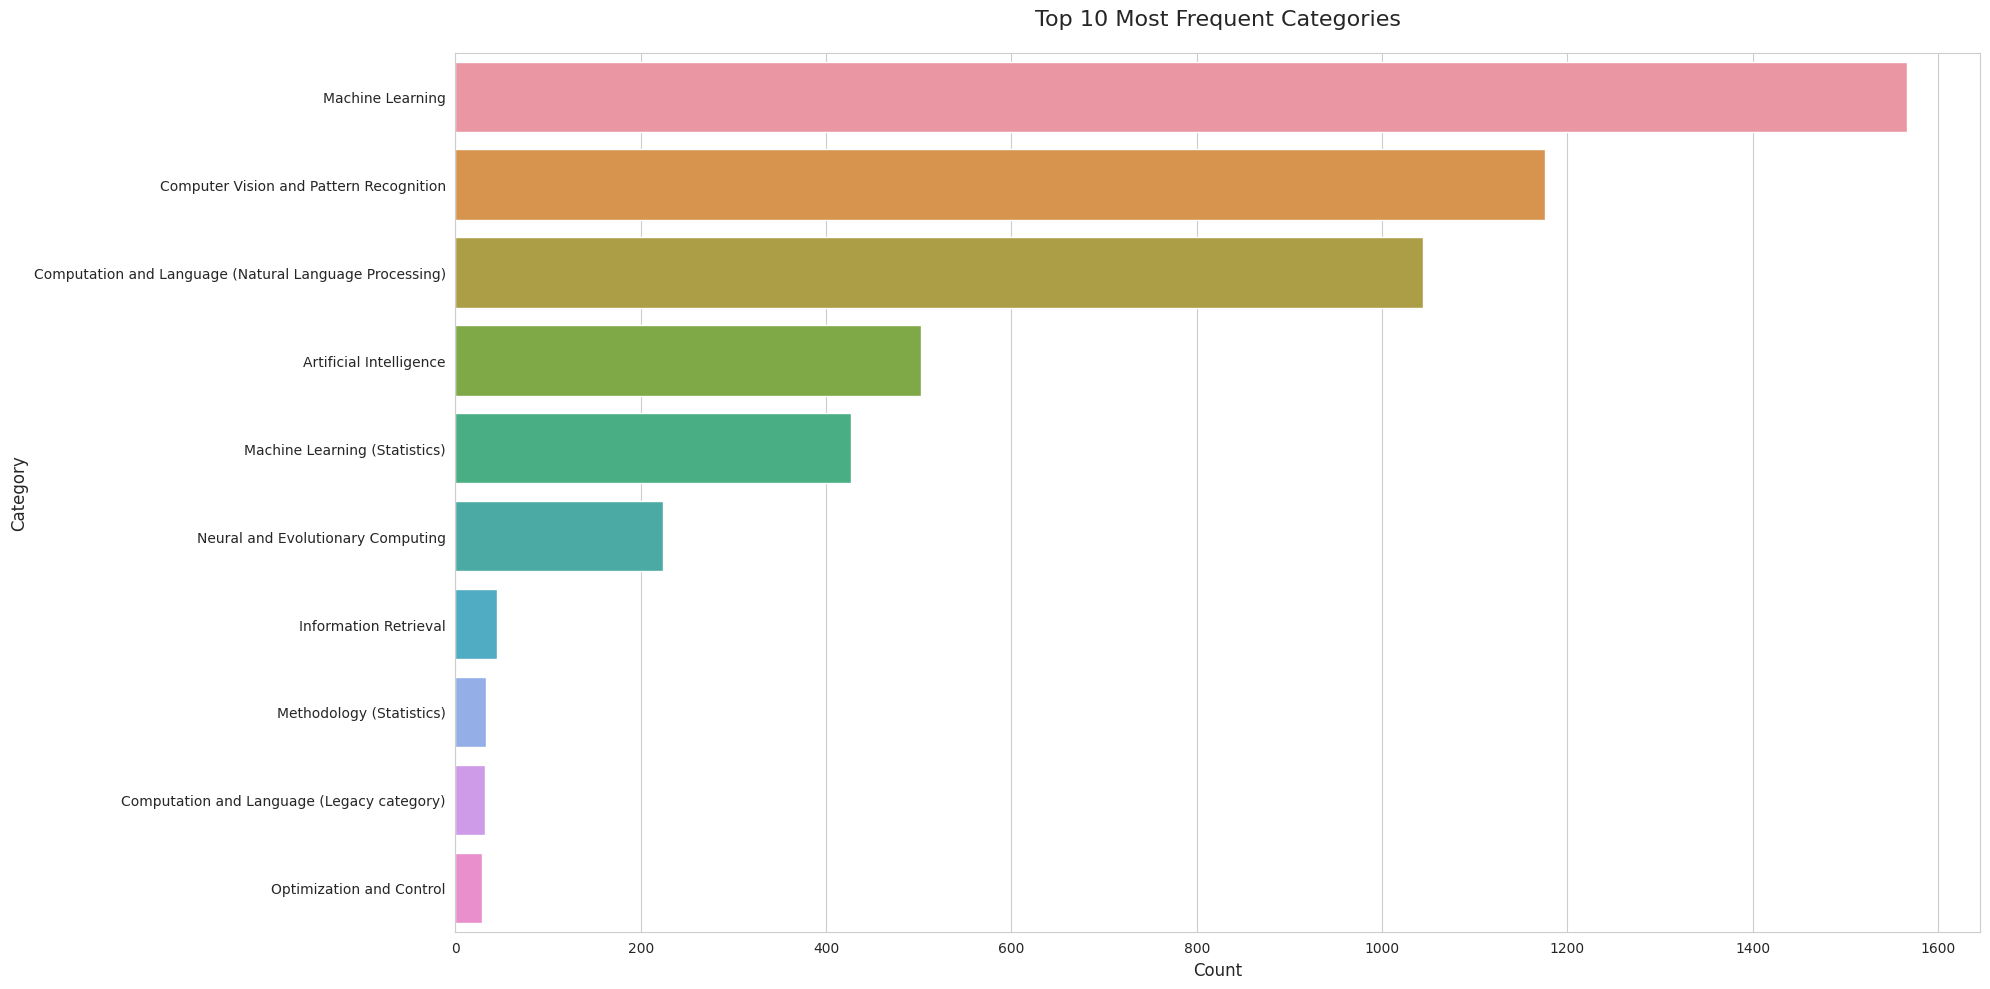

In [ ]:
def visualize_top_categories(df):
    """
    Analyzes a DataFrame with a 'category' column to find the top 10
    most frequent categories and visualizes the results.

    Args:
        df (pd.DataFrame): DataFrame with a 'category' column.
    """
    category_counts = df['category'].value_counts().reset_index()
    category_counts.columns = ['Category', 'Count']

    top_10_categories = category_counts.nlargest(10, 'Count')

    sns.set_style("whitegrid")
    sns.set_palette("viridis")

    plt.figure(figsize=(20, 10))

    sns.barplot(
        x='Count',
        y='Category',
        data=top_10_categories,
        orient='h'
    )

    plt.title('Top 10 Most Frequent Categories', fontsize=16, pad=20)
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Category', fontsize=12)

    plt.tight_layout()
    plt.show()

visualize_top_categories(train)

**Interpretation of Category Distribution**

The bar chart showing the "Top 10 Most Frequent Categories" reveals a distinct thematic hierarchy in the sampled corpus:

- Dominance of Machine Learning (ML): The categories Machine Learning, Computer Vision and Pattern Recognition, and Computation and Language (Natural Language Processing) are overwhelmingly the most frequent. This indicates that the core research focus of the current arXiv sample is heavily skewed towards modern AI and related computational fields.
- Thematic Clusters: The categories form logical clusters: pure ML, application-specific ML (Vision and Language), and foundational fields (Artificial Intelligence, and Machine Learning (Statistics)).
- Implication for Topic Modeling: Given this distribution, the LDA model is expected to primarily uncover topics within the realm of computer science, such as "Neural Networks," "Image Segmentation," and "Language Generation." The model will need to be effective at distinguishing subtle differences within the Machine Learning domain, rather than separating wildly disparate subjects (like astrophysics and economics).

**Word Frequency Visualization (WordCloud)**

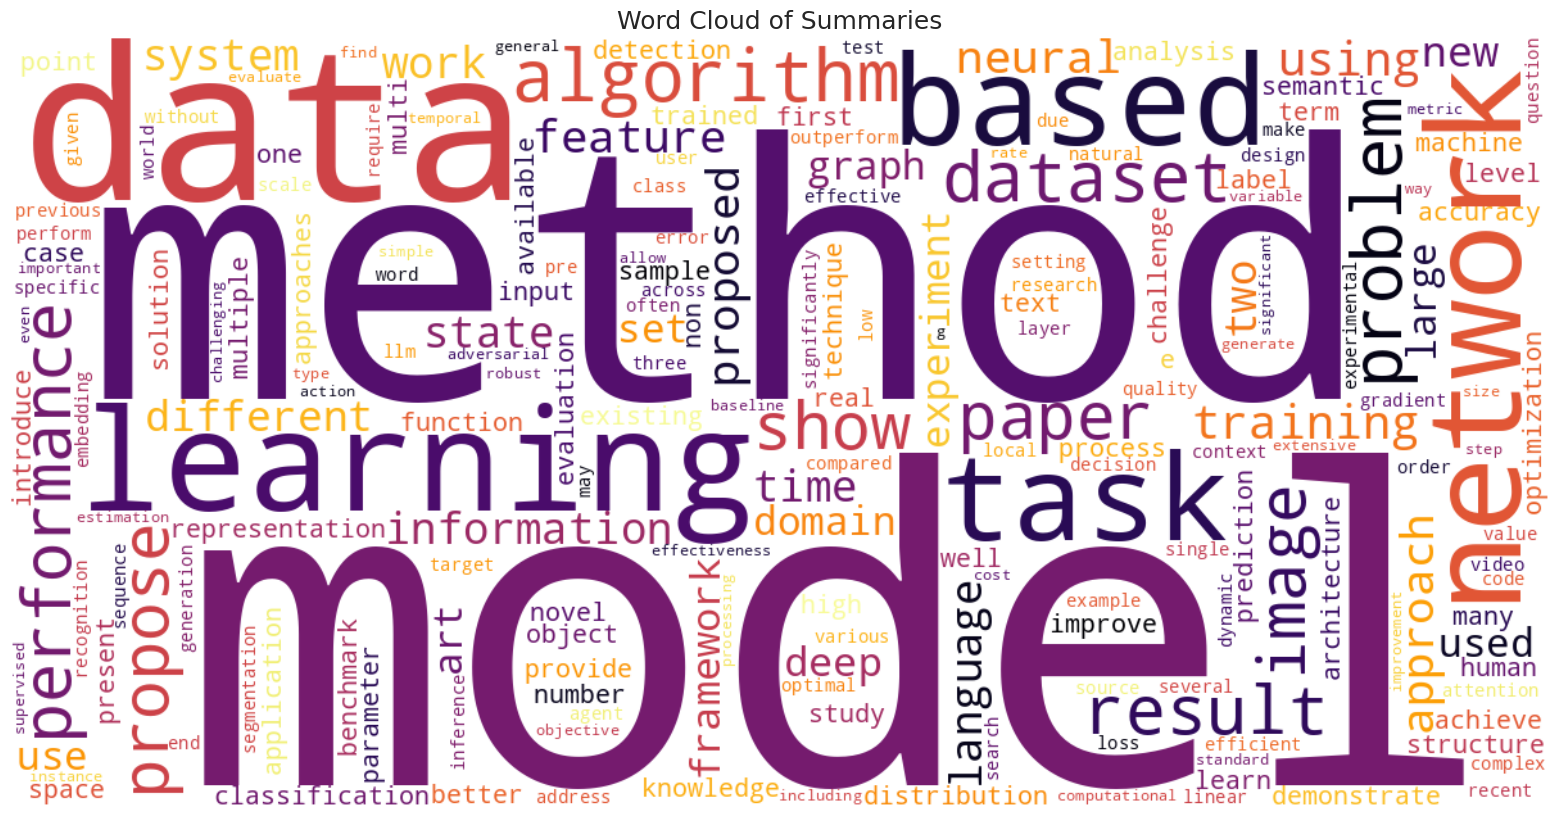

In [ ]:
def create_wordcloud(df):
    """
    Generates and displays a word cloud from the 'summary' column of a DataFrame.

    Args:
        df (pd.DataFrame): DataFrame with a 'summary' column.
    """
    all_text = ' '.join(
        df['summary']
        .astype(str)
        .str.lower()
        .dropna()
    )

    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        colormap='inferno',
        max_words=200,
        collocations=False
    ).generate(all_text)

    plt.figure(figsize=(20, 10))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Summaries', fontsize=18)
    plt.show()

create_wordcloud(train)

**Interpretation of the Word Cloud**

The word cloud generated from the training set's summaries provides a global view of the corpus vocabulary:

- High-Frequency Terms: The largest and most frequent words include: model, method, data, learning, network, algorithm, problem, and system.
- Confirmation of Subject Matter: These terms strongly confirm the findings from the category distribution. They are the essential, high-level vocabulary of contemporary computer science research, particularly AI and machine learning methodologies.
- Implication for Pre-processing: While these terms are relevant, they are also highly generic within the field (e.g., almost every paper uses "model" and "method"). This observation validates the decision to implement aggressive preprocessing, specifically Part-of-Speech (POS) filtering and stop-word removal, to move beyond these overly generic terms and isolate the more discriminating, theme-specific vocabulary that defines distinct topics (e.g., distinguishing between a "GAN model" and a "Transformer model").

# Features Engineering

The goal of this phase is to maximize the signal-to-noise ratio in the text data, ensuring that the Latent Dirichlet Allocation (LDA) model receives only the most informative, semantically core tokens. This is achieved through a multi-stage pipeline combining general clean-up with advanced linguistic processing using spaCy.

**Fetures and Target Labels Split**

In [ ]:
x_train = train[["summary"]]
x_test = test[["summary"]]

print("Shape of X_train:", x_train.shape)
print("Shape of X_test:", x_test.shape)

Shape of X_train: (5449, 1)
Shape of X_test: (1363, 1)


**Data Preprocess Pipeline and Data Preprocess Pipeline Visualization**

In [ ]:
def clean_text(text):
    """
    Performs basic text cleaning: contraction expansion, lowercase,
    punctuation/number/stopword removal.

    Args:
        text (str): The input text to be cleaned.

    Returns:
        str: The cleaned text string.
    """
    if pd.isna(text):
        return ''

    text = str(text)

    text = contractions.fix(text)

    text = text.lower()

    if text.strip() in ['no negative', 'nothing', 'no positive']:
        return ''

    text = re.sub(r'[\d' + re.escape(string.punctuation) + ']+', '', text)

    stop_words = set(stopwords.words('english'))
    words = text.split()
    cleaned_words = [
        word
        for word in words
        if word not in stop_words and len(word) > 1
    ]

    return ' '.join(cleaned_words)


def lemmatize_text(text):
    """
    Uses spaCy to perform lemmatization on a text string.
    
    Args:
        text (str): The text to process.

    Returns:
        str: The lemmatized text string.
    """
    doc = nlp(text)

    lemmas = [token.lower_ if token.lemma_ == "-PRON-" else token.lemma_ for token in doc]
    
    return " ".join(lemmas)

def filter_by_pos(text):
    """
    Filters a text string to keep only specified parts of speech.
    
    Args:
        text (str): The text string to filter.
        
    Returns:
        str: The filtered text string containing only allowed POS tags.
    """
    doc = nlp(text)

    allowed_pos = {'NOUN', 'PROPN', 'ADJ', 'VERB'}

    filtered_tokens = [token.text for token in doc if token.pos_ in allowed_pos]

    return " ".join(filtered_tokens)



sample_review = "We stayed at the Marriott hotel in New York City for 2 nights in August 2024. We booked the room through Expedia and were very pleased with the discount we received. The receptionist, a very kind Brazilian man named Carlos, made our check-in seamless. The hotel is located right next to Central Park. Overall, the staff were fantastic and we will be back!"

print("="*50)
print("Step 1: Original Review Text")
print("="*50)
print(sample_review)

cleaned_text = clean_text(sample_review)
print("\n" + "="*50)
print("Step 2: Cleaned Text")
print("="*50)
print(cleaned_text)

lemmatized_doc = nlp(cleaned_text)
print("\n" + "="*50)
print("Step 3: Lemmatization Word-by-Word")
print("="*50)
for token in lemmatized_doc:
    print(f"{token.text} => {token.lemma_}")

lemmatized_text = " ".join([token.lower_ if token.lemma_ == "-PRON-" else token.lemma_ for token in lemmatized_doc])
print("\n" + "="*50)
print("Step 3: Lemmatized Text")
print("="*50)
print(lemmatized_text)


pos_doc = nlp(lemmatized_text)
print("\n" + "="*50)
print("Step 4: Part-of-Speech (POS) Tagging")
print("="*50)
for token in pos_doc:
    print(f"{token.text} => {token.pos_}")

final_processed_text = filter_by_pos(lemmatized_text)
print("\n" + "="*50)
print("Step 5: Final Preprocessed Text (After POS Filtering)")
print("="*50)
print(final_processed_text)

Step 1: Original Review Text
We stayed at the Marriott hotel in New York City for 2 nights in August 2024. We booked the room through Expedia and were very pleased with the discount we received. The receptionist, a very kind Brazilian man named Carlos, made our check-in seamless. The hotel is located right next to Central Park. Overall, the staff were fantastic and we will be back!

Step 2: Cleaned Text
stayed marriott hotel new york city nights august booked room expedia pleased discount received receptionist kind brazilian man named carlos made checkin seamless hotel located right next central park overall staff fantastic back

Step 3: Lemmatization Word-by-Word
stayed => stay
marriott => marriott
hotel => hotel
new => new
york => york
city => city
nights => night
august => august
booked => book
room => room
expedia => expedia
pleased => pleased
discount => discount
received => receive
receptionist => receptionist
kind => kind
brazilian => brazilian
man => man
named => name
carlos =>

## Text Cleaning and Text Normalization

The `clean_text` function handles the initial normalization:

- Contraction Expansion: Contractions (e.g., "we'll") are expanded to their full form ("we will"). This ensures consistent representation of vocabulary.
- Lower-casing: All text is converted to lowercase to treat the same word identically regardless of its capitalization.
- Noise Removal: Punctuation and numerical digits are removed using regular expressions (re). These elements do not contribute to the abstract's scientific theme.
- Stop-word Removal: High-frequency, common English words (like "a," "is," "the") are removed using the NLTK list. These words are uninformative and dilute the distinctiveness of topics.

**Term Frequency Normalization**

These steps are forms of term normalization. By removing noise and standardizing word forms, we reduce the total size of the vocabulary, which makes the subsequent vectorization more efficient and ensures that the model focuses its computational power on the meaningful terms.

In [ ]:
def clean_text(text):
    """
    Performs basic text cleaning: contraction expansion, lowercase,
    punctuation/number/stopword removal.

    Args:
        text (str): The input text to be cleaned.

    Returns:
        str: The cleaned text string.
    """
    if pd.isna(text):
        return ''

    text = str(text)

    text = contractions.fix(text)

    text = text.lower()

    text = re.sub(r'[\d' + re.escape(string.punctuation) + ']+', '', text)

    stop_words = set(stopwords.words('english'))
    words = text.split()
    cleaned_words = [
        word
        for word in words
        if word not in stop_words and len(word) > 1
    ]

    return ' '.join(cleaned_words)

def clean_dataframe(df, column_name):
    """
    Applies the text cleaning pipeline to a single DataFrame column.

    Args:
        df (pd.DataFrame): The DataFrame to process.
        column_name (str): The name of the text column to clean.

    Returns:
        pd.DataFrame: A DataFrame with a new column for cleaned text.
    """
    cleaned_column_name = 'cleaned_' + column_name
    print(f"Applying text cleaning to '{column_name}' and creating a new column '{cleaned_column_name}'...")
    df[cleaned_column_name] = df[column_name].apply(clean_text)
    return df

x_train = clean_dataframe(x_train, 'summary')
x_test = clean_dataframe(x_test, 'summary')

Applying text cleaning to 'summary' and creating a new column 'cleaned_summary'...


/tmp/ipykernel_36/725629347.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[cleaned_column_name] = df[column_name].apply(clean_text)


Applying text cleaning to 'summary' and creating a new column 'cleaned_summary'...


/tmp/ipykernel_36/725629347.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[cleaned_column_name] = df[column_name].apply(clean_text)


## Advanced Linguistic Processing (Lemmatization and POS Tagging)

These stages are critical for improving Topic Coherence by ensuring word forms are unified and only content-bearing tokens remain.

### Lemmatization

The `lemmatize_text` function uses the advanced linguistic capabilities of spaCy to reduce words to their base or dictionary form (lemma). For example, "estimating" and "estimated" both become "estimate."

**Lexical Unification**

Lemmatization is superior to simple stemming because it considers the word's Part-of-Speech (POS) to ensure the reduction is linguistically correct (e.g., distinguishing between "mining" as a noun and "mining" as a verb). This lexical unification prevents the model from treating different conjugations of the same concept as separate words, thus concentrating the thematic weight onto the single, correct root word.

In [ ]:
def lemmatize_text(text):
    """
    Uses spaCy to perform lemmatization on a text string.
    
    Args:
        text (str): The text to process.

    Returns:
        str: The lemmatized text string.
    """
    doc = nlp(text)

    lemmas = [token.lower_ if token.lemma_ == "-PRON-" else token.lemma_ for token in doc]
    
    return " ".join(lemmas)

print("\nApplying spaCy lemmatization...")
x_train['lemmatized_summary'] = x_train['cleaned_summary'].progress_apply(lemmatize_text)
x_test['lemmatized_summary'] = x_test['cleaned_summary'].progress_apply(lemmatize_text)
x_train


Applying spaCy lemmatization...


100%|██████████| 1363/1363 [00:37<00:00, 36.32it/s]


,summary,cleaned_summary,lemmatized_summary
70405,"Self-supervised monocular depth estimation, ai...",selfsupervised monocular depth estimation aimi...,selfsupervise monocular depth estimation aimin...
85225,We present a new open-source framework for for...,present new opensource framework forecasting p...,present new opensource framework forecasting p...
121330,In the retrieval-based multi-turn dialogue mod...,retrievalbased multiturn dialogue modeling rem...,retrievalbased multiturn dialogue modeling rem...
96041,Despite being impactful on a variety of proble...,despite impactful variety problems application...,despite impactful variety problem application ...
46239,"Tensor Kronecker products, the natural general...",tensor kronecker products natural generalizati...,tensor kronecker product natural generalizatio...
...,...,...,...
95172,This paper describes an implementation of the ...,paper describes implementation lbfgs method de...,paper describe implementation lbfgs method des...
114928,Rating scales are a widely used method for dat...,rating scales widely used method data annotati...,rating scale widely use method datum annotatio...
120365,Despite impressive empirical successes of neur...,despite impressive empirical successes neural ...,despite impressive empirical success neural ma...
110417,We utilize machine learning models which are b...,utilize machine learning models based recurren...,utilize machine learning model base recurrent ...


### POS Tagging

The `filter_by_pos` function is applied last. It filters the lemmatized text to retain only tokens tagged as NOUN, PROPN (Proper Noun), ADJ (Adjective), or VERB.

**Content-Bearing Tokens**

This step implements the crucial concept of isolating content-bearing tokens. Prepositions, conjunctions, adverbs, and other functional words carry little thematic information. By discarding them, we focus the LDA model entirely on the entities (Nouns, Proper Nouns), descriptors (Adjectives), and actions (Verbs) central to the research abstract, leading to significantly clearer and more interpretable topics.

In [ ]:
def filter_by_pos(text):
    """
    Filters a text string to keep only specified parts of speech.
    
    Args:
        text (str): The text string to filter.
        
    Returns:
        str: The filtered text string containing only allowed POS tags.
    """
    doc = nlp(text)

    allowed_pos = {'NOUN', 'PROPN', 'ADJ', 'VERB'}

    filtered_tokens = [token.text for token in doc if token.pos_ in allowed_pos]

    return " ".join(filtered_tokens)

print("\nApplying POS tagging and filtering...")
x_train['processed_summary'] = x_train['lemmatized_summary'].progress_apply(filter_by_pos)
x_test['processed_summary'] = x_test['lemmatized_summary'].progress_apply(filter_by_pos)
x_train


Applying POS tagging and filtering...


100%|██████████| 1363/1363 [00:37<00:00, 36.18it/s]


,summary,cleaned_summary,lemmatized_summary,processed_summary
70405,"Self-supervised monocular depth estimation, ai...",selfsupervised monocular depth estimation aimi...,selfsupervise monocular depth estimation aimin...,selfsupervise monocular depth estimation aimin...
85225,We present a new open-source framework for for...,present new opensource framework forecasting p...,present new opensource framework forecasting p...,present new opensource framework forecasting p...
121330,In the retrieval-based multi-turn dialogue mod...,retrievalbased multiturn dialogue modeling rem...,retrievalbased multiturn dialogue modeling rem...,retrievalbased multiturn dialogue modeling rem...
96041,Despite being impactful on a variety of proble...,despite impactful variety problems application...,despite impactful variety problem application ...,impactful variety problem application generati...
46239,"Tensor Kronecker products, the natural general...",tensor kronecker products natural generalizati...,tensor kronecker product natural generalizatio...,tensor kronecker product natural generalizatio...
...,...,...,...,...
95172,This paper describes an implementation of the ...,paper describes implementation lbfgs method de...,paper describe implementation lbfgs method des...,paper implementation lbfgs method design deal ...
114928,Rating scales are a widely used method for dat...,rating scales widely used method data annotati...,rating scale widely use method datum annotatio...,rating scale use method datum annotation prese...
120365,Despite impressive empirical successes of neur...,despite impressive empirical successes neural ...,despite impressive empirical success neural ma...,impressive empirical success neural machine tr...
110417,We utilize machine learning models which are b...,utilize machine learning models based recurren...,utilize machine learning model base recurrent ...,utilize machine learning model base recurrent ...


In [17]:
x_train = x_train[["processed_summary"]]
x_test = x_test[["processed_summary"]]

**Preprocessed Data Visualization**

In [18]:
print("\n" + "="*50)
print("Data After Full Preprocessing:")
print("="*50)
print(x_train)


Data After Full Preprocessing:
                                        processed_summary
70405   selfsupervise monocular depth estimation aimin...
85225   present new opensource framework forecasting p...
121330  retrievalbased multiturn dialogue modeling rem...
96041   impactful variety problem application generati...
46239   tensor kronecker product natural generalizatio...
...                                                   ...
95172   paper implementation lbfgs method design deal ...
114928  rating scale use method datum annotation prese...
120365  impressive empirical success neural machine tr...
110417  utilize machine learning model base recurrent ...
96386   deep learning apply many securitysensitive app...

[5449 rows x 1 columns]


## Text Representation (Vectorization and Gensim Conversion)

Once the text is cleaned and tokenized, it must be mathematically represented for the LDA model. This conversion is handled by standardizing the text data into the required Gensim format.

### Document-Term Matrix Creation (CountVectorizer)

The CountVectorizer is applied to the training data's `processed_summary` column to create the Document-Term Matrix (DTM).

**Bag-of-Words Model**

The DTM represents the data using the Bag-of-Words (BoW) model. Each row corresponds to a document (abstract), and each column corresponds to a unique word (term) in the corpus. The value in each cell is the raw frequency count of that term in that document. This process extracts the entire vocabulary (terms list) and transforms the abstract text into a high-dimensional, sparse numerical matrix, which is the input standard for many traditional NLP models.

In [ ]:
print("\n Creating a Document-Term Matrix (CountVectorizer)")
vectorizer = CountVectorizer()
doc_term_matrix = vectorizer.fit_transform(x_train['processed_summary'])
doc_term_matrix_test = vectorizer.transform(x_test['processed_summary'])
terms = vectorizer.get_feature_names_out()


 Creating a Document-Term Matrix (CountVectorizer)


### Gensim Conversion

**Document-Term Matrix to Gensim's Dictionary and Corpus format**

The DTM output, while standard for scikit-learn, needs to be converted into the proprietary format used by the Gensim library for LDA training:

- Gensim Dictionary: This object is created by mapping the term names generated by the CountVectorizer to unique integer IDs. This acts as the official vocabulary lookup for the model.
- Gensim Corpus: The DTM is converted into a list of lists, where each inner list represents a document as a sequence of (`word_id, word_count`) tuples.

**Sparse Data Efficiency**

Gensim's corpus format maintains sparsity, meaning it only stores the word IDs and counts for words that actually appear in a document, rather than storing a zero for every word that does not. This is crucial for memory management and computational speed when dealing with tens of thousands of documents and tens of thousands of unique terms (the 24,786 unique tokens seen in the dictionary output). The final `gensim_corpus` is now ready to be passed directly to the LdaModel for training.

In [ ]:
print("\nConverting Document-Term Matrix to Gensim format...")
gensim_dictionary = Dictionary.from_corpus(
    corpus=Sparse2Corpus(doc_term_matrix),
    id2word=dict(enumerate(terms))
)
gensim_corpus = [gensim_dictionary.doc2bow(doc.split()) for doc in x_train['processed_summary']]
print("Gensim Dictionary:", gensim_dictionary)
print("Example of Gensim Corpus (first document):", gensim_corpus[0])


Converting Document-Term Matrix to Gensim format...
Gensim Dictionary: Dictionary<24786 unique tokens: ['aa', 'aaai', 'aachen', 'aae', 'aaia']...>
Example of Gensim Corpus (first document): [(23, 1), (29, 1), (115, 1), (228, 2), (232, 1), (460, 1), (561, 1), (700, 1), (707, 1), (951, 1), (1198, 1), (1346, 1), (2318, 1), (2376, 1), (2449, 1), (3132, 1), (3135, 1), (3152, 1), (3367, 1), (3689, 3), (3772, 2), (4173, 1), (4869, 2), (4950, 13), (4996, 1), (5310, 2), (6003, 1), (6005, 1), (6016, 1), (6302, 1), (6305, 2), (6677, 3), (6836, 1), (6872, 2), (7314, 1), (7361, 2), (8168, 1), (8328, 1), (8760, 1), (9636, 1), (10050, 2), (10186, 1), (10415, 1), (10565, 1), (11337, 1), (11713, 5), (12512, 1), (12578, 1), (12592, 1), (12600, 4), (13190, 3), (13205, 2), (13697, 1), (13745, 2), (13972, 1), (14442, 1), (14507, 1), (15102, 1), (15273, 2), (15274, 2), (15292, 3), (15526, 1), (15774, 1), (15931, 1), (17277, 2), (17295, 1), (17426, 5), (18133, 1), (18136, 1), (18477, 1), (18649, 1), (18730,

## Tokenization

The documents are also tokenized into a simple list of strings (`tokenized_docs`) at this stage, which is the format required later for the Topic Coherence calculation.

In [21]:
tokenized_docs = [doc.split() for doc in x_train['processed_summary']]
tokenized_docs = [doc.split() for doc in x_test['processed_summary']]

# Latent Dirichlet Allocation (LDA) Model Training

**Latent Dirchlet Allocation (LDA) - GENSIM**

The initial code block focuses on training the LDA model using the Gensim library. 

**Model Initialization**

The LdaModel is instantiated using the previously prepared textual data: 
- the `gensim_corpus` (the Bag-of-Words representation of the documents) and the `gensim_dictionary` (the vocabulary mapping).
- Key hyperparameters are set: `num_topics` (initially 5 for demonstration), `random_state` (for reproducibility), and `passes` (the number of training iterations).

**Generative Probabilistic Model**

LDA is an unsupervised, generative probabilistic model that operates on the fundamental assumption that texts are created from latent (hidden) thematic structures. It posits that every document is a mix of various topics, and every topic is a mix of words. The training process uses techniques like Gibbs Sampling or Variational Inference to deduce two key distributions:
- Topic-Word Distribution ($phi$): The probability of specific words being generated by a specific topic. This distribution is used to produce the list of top keywords for each topic (e.g., Topic 1: "algorithm," "problem," "model," "use," "method").
- Document-Topic Distribution ($theta$): The proportion of each topic present in any given document. This distribution is the primary input for the visualization phase.

The output topic lists, such as the one for Topic 2: "network" and "neural," indicate that the model has successfully identified a thematic cluster likely related to deep learning or neural network research within the corpus.

In [ ]:
num_topics = 5
print(f"\nTraining LDA model with {num_topics} topics...")
lda_model = LdaModel(
    corpus=gensim_corpus,
    id2word=gensim_dictionary,
    num_topics=num_topics,
    random_state=100,
    passes=10,
    per_word_topics=True
)


Training LDA model with 5 topics...


## Prediction Results

In [ ]:
print("\n" + "="*50)
print("Discovered Topics:")
print("="*50)
for idx, topic in lda_model.print_topics(num_words=5):
    print(f"Topic: {idx+1} \nWords: {topic}\n")


Discovered Topics:
Topic: 1 
Words: 0.018*"algorithm" + 0.014*"problem" + 0.011*"model" + 0.011*"use" + 0.010*"method"

Topic: 2 
Words: 0.027*"network" + 0.016*"neural" + 0.009*"use" + 0.007*"model" + 0.006*"system"

Topic: 3 
Words: 0.021*"datum" + 0.014*"model" + 0.012*"method" + 0.011*"use" + 0.009*"propose"

Topic: 4 
Words: 0.024*"model" + 0.014*"language" + 0.011*"task" + 0.010*"use" + 0.007*"system"

Topic: 5 
Words: 0.015*"model" + 0.015*"network" + 0.014*"method" + 0.014*"image" + 0.013*"propose"



## Topic Clusters Visualization (Initial Hyperparameters)

**Document-Topic Matrix Preparation**

Before visualization can occur, the high-dimensional output of the LDA model must be consolidated into a dense matrix.

**Approach : Feature Extraction**

The `lda_model.get_document_topics()` method is used to extract the $theta$ distribution for every document in the corpus. This data is initially in a sparse Gensim format, listing only the topics with non-zero probability for each document. The code then converts this sparse output into a dense NumPy array (`doc_topic_matrix_dense`) with dimensions $D * N$, where $D$ is the number of documents and $N$ is the number of topics.

**Feature Space**

The resulting matrix defines the feature space for visualization. In this space, each document is represented as a single point defined by its topic probabilities. Two documents that are semantically similar—because they share a similar blend of topics—will have topic vectors that are close to each other in this high-dimensional space.

In [ ]:
doc_topic_matrix = lda_model.get_document_topics(gensim_corpus, minimum_probability=0.0)

num_topics = lda_model.num_topics
doc_topic_matrix_dense = np.zeros((len(gensim_corpus), num_topics))
for i, doc_topics in enumerate(doc_topic_matrix):
    for topic_id, score in doc_topics:
        doc_topic_matrix_dense[i, topic_id] = score

**Visualization with Dimensionality Reduction (UMAP and t-SNE)**

The core visualization step involves using non-linear dimensionality reduction techniques to project the high-dimensional document-topic matrix into a two-dimensional scatter plot.

**Approach: Mapping to 2D**

The `doc_topic_matrix_dense` is passed to both the UMAP (`umap.UMAP`) and t-SNE (`TSNE`) algorithms. Both are configured to reduce the data to two components (`n_components=2`). The resulting 2D coordinates are then plotted. The scatter points are colored using the categorical codes derived from the `x_train["processed_summary"]` column, allowing the visualization to check if the latent topics found by LDA align with any existing document categories.

**Manifold Learning**

Both UMAP and t-SNE are forms of manifold learning, designed to uncover the underlying low-dimensional structure (the "manifold") of the high-dimensional data.

- t-SNE (t-distributed Stochastic Neighbor Embedding): Primarily focuses on accurately preserving the local structure, meaning documents that are very close in topic space will remain close in the plot. It tends to create compact, well-separated clusters, but the distance between those clusters is often meaningless.
- UMAP (Uniform Manifold Approximation and Projection): A newer method that aims to preserve both local and global structure more effectively than t-SNE. The relative distances between clusters in a UMAP plot can often be interpreted more reliably.

**Visualization with Dimensionality Reduction (UMAP)**


Visualizing Topics with UMAP

Creating UMAP embedding...


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


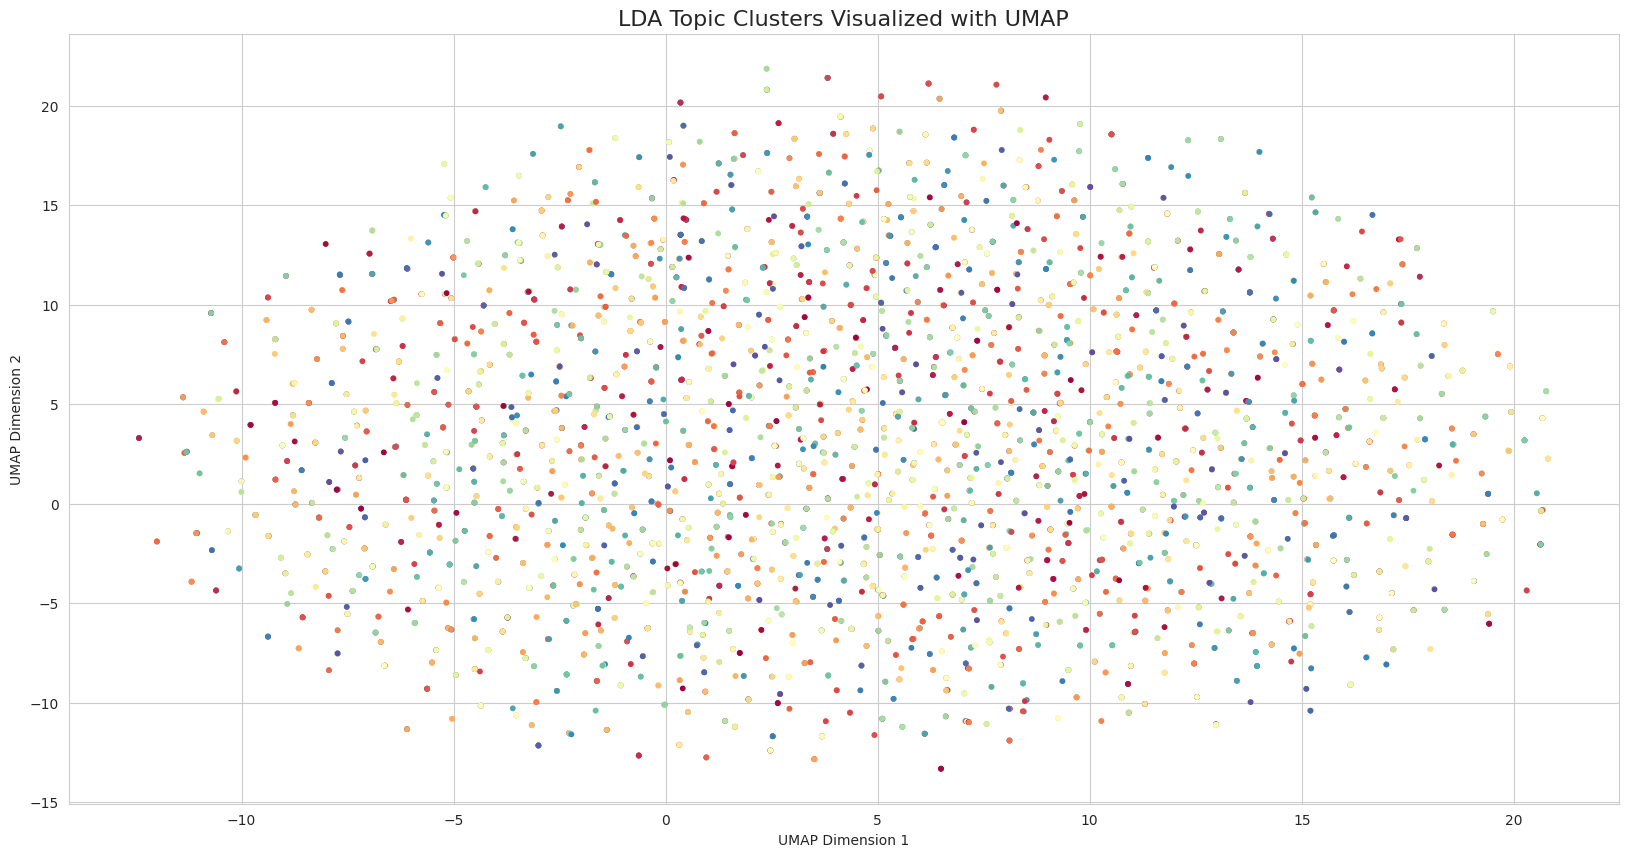

In [ ]:
print("\n" + "="*50)
print("Visualizing Topics with UMAP")
print("="*50)

print("\nCreating UMAP embedding...")
embedding = umap.UMAP(n_neighbors=2, random_state=42).fit_transform(doc_topic_matrix_dense)

plt.figure(figsize=(20, 10))
plt.title("LDA Topic Clusters Visualized with UMAP", fontsize=16)

plt.scatter(embedding[:, 0], embedding[:, 1],
            c=x_train["processed_summary"].astype('category').cat.codes,
            cmap='Spectral', alpha=1.0, s=10)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()

**Visualization with Dimensionality Reduction (t-SNE)**


Visualizing Topics with t-SNE

Creating t-SNE embedding...


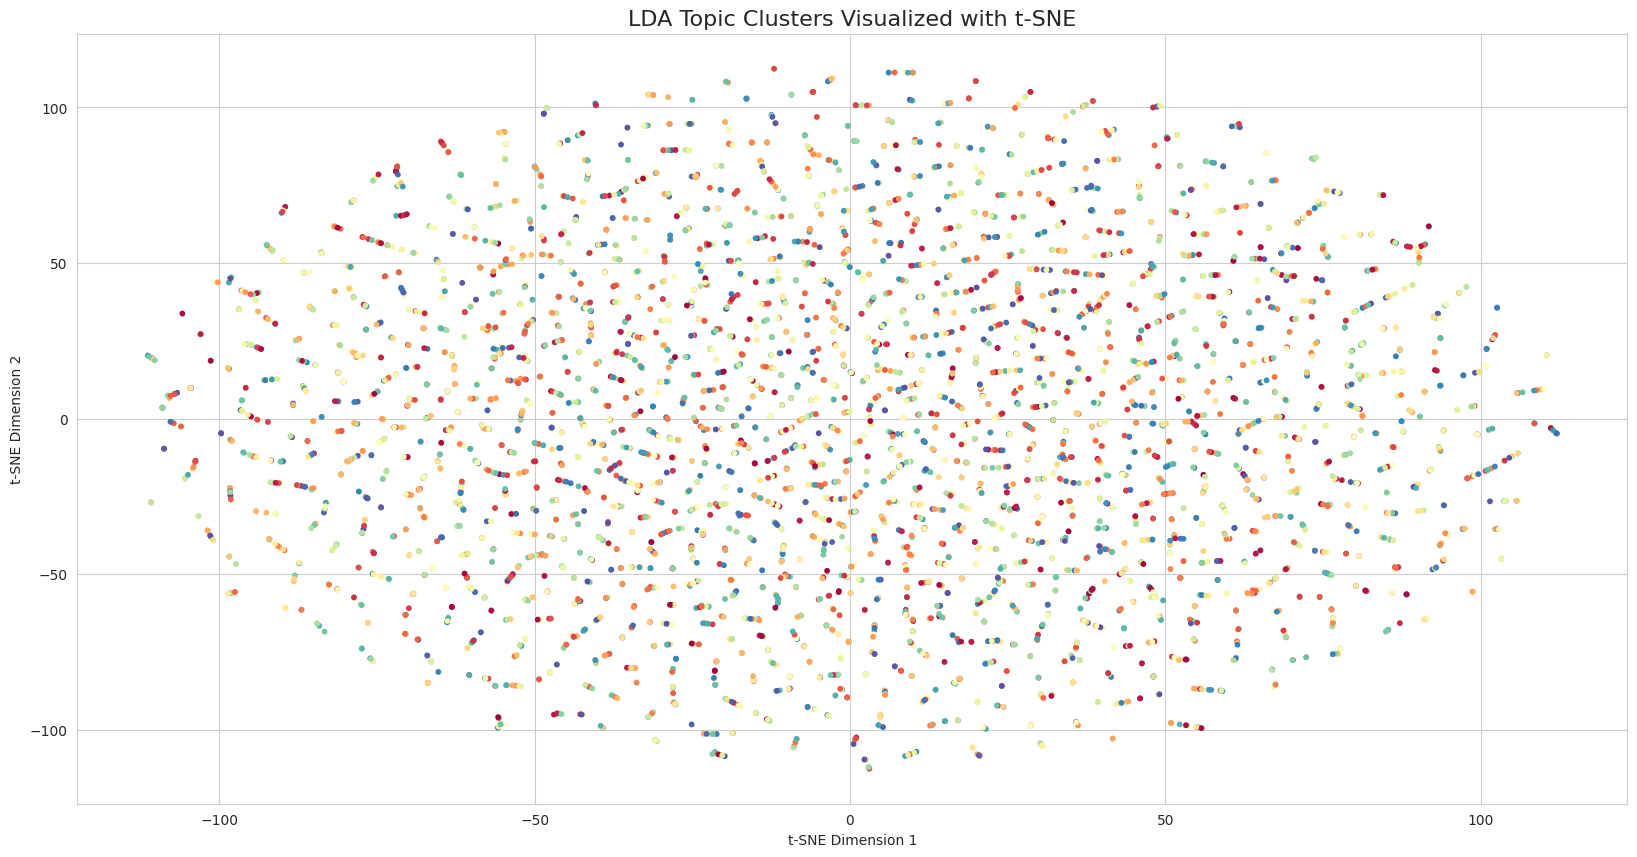

In [ ]:
print("\n" + "="*50)
print("Visualizing Topics with t-SNE")
print("="*50)

print("\nCreating t-SNE embedding...")
tsne_model = TSNE(n_components=2, random_state=42, perplexity=2.0)
tsne_embedding = tsne_model.fit_transform(doc_topic_matrix_dense)

plt.figure(figsize=(20, 10))
plt.title("LDA Topic Clusters Visualized with t-SNE", fontsize=16)

plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1],
            c=x_train["processed_summary"].astype('category').cat.codes,
            cmap='Spectral', alpha=1.0, s=10)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

**Interpretation of the Visualization Plots**

Both the UMAP and t-SNE plots exhibit a common pattern:

- Dense, Amorphous Cloud: The primary characteristic is that the documents form a single, large, dense cloud rather than multiple distinct, separated clusters. This indicates a high degree of semantic overlap across the corpus. The documents are not cleanly separable into pure topic groups; instead, most documents are complex mixtures of multiple topics. In a technical or academic dataset, this is typical, as research papers or articles often combine concepts from related themes (e.g., an article on "Neural Networks" will likely contain terms from "Algorithm" and "Model" topics).

- Color Diffusion: The colors (representing the original document categories) are thoroughly dispersed and intermingled throughout the cloud. There are no strong, concentrated color patches. This suggests that the latent topics discovered by the LDA model do not perfectly align with the preexisting categories of the documents. If a category (e.g., "Computer Vision") corresponded to a single, distinct topic, all points of that color would form a tight, isolated cluster. The observed blending shows that the semantic structure found by LDA cuts across or blends the original document groupings.

**Conclusion:** The visualization confirms that the corpus is a highly interconnected semantic space. While LDA successfully decomposed the texts into topic components, the documents themselves are too interdisciplinary or semantically mixed to form clear, discrete clusters in the lower-dimensional projection.

## Number of Topics Experiment

**What happen with (Topics Coherence Score) if we adjusting hyperparameter (Number of Topics) in LDA model?**

The primary goal of this section is to solve a fundamental challenge in unsupervised topic modeling: determining the optimal number of latent topics ($K$). The code employs a systematic approach known as grid search, evaluated by the Topic Coherence metric.

**Approach: Coherence-Based Grid Search**

The process involves iteratively training the LDA model with a predefined range of topic counts (from 2 to 9, in this example). For each iteration, the following steps are executed:

- Model Training: An LDA model is trained using the Bag-of-Words corpus (gensim_corpus) and dictionary, with the specific number of topics ($K$).
- Top Word Extraction: The top words for each of the $K$ topics are extracted to represent the topic's semantic content.
- Coherence Calculation: The $C_v$ Coherence Metric is calculated for the entire set of $K$ topics using the CoherenceModel in Gensim. This score quantifies the semantic quality.
- Optimal Selection: The model configuration (the value of $K$) that yields the highest coherence score is retained as the best model for the dataset, as it produces the most semantically meaningful and interpretable topics.

**Topic Coherence as an Intrinsic Quality Metric**

The Topic Coherence score is an intrinsic evaluation metric used to assess the quality of a topic model. It measures how often the top words of a topic co-occur together in the documents of the corpus.

- Semantic Intuition: A high coherence score implies that the words grouped together within a topic are semantically related and logically belong in the same cluster, making the topic easy for a human to interpret and label (e.g., if a topic contains "network," "neural," and "algorithm," it is highly coherent and clearly relates to deep learning).
- Contrast with Perplexity: Unlike Perplexity (an extrinsic measure of the model's generalization ability, where lower is better), coherence is directly correlated with human interpretability, making it the preferred metric for selecting $K$ in most real-world applications.


Adjust hyperparameters for LDA Model

> Training LDA model with 2 topics...
  Coherence Score: 0.3426

> Training LDA model with 3 topics...
  Coherence Score: 0.3608

> Training LDA model with 4 topics...
  Coherence Score: 0.3718

> Training LDA model with 5 topics...
  Coherence Score: 0.3962

> Training LDA model with 6 topics...
  Coherence Score: 0.3863

> Training LDA model with 7 topics...
  Coherence Score: 0.4103

> Training LDA model with 8 topics...
  Coherence Score: 0.4215

> Training LDA model with 9 topics...
  Coherence Score: 0.4133

Tuning Complete
Optimal number of topics (n_components): 8
Highest coherence score: 0.4215


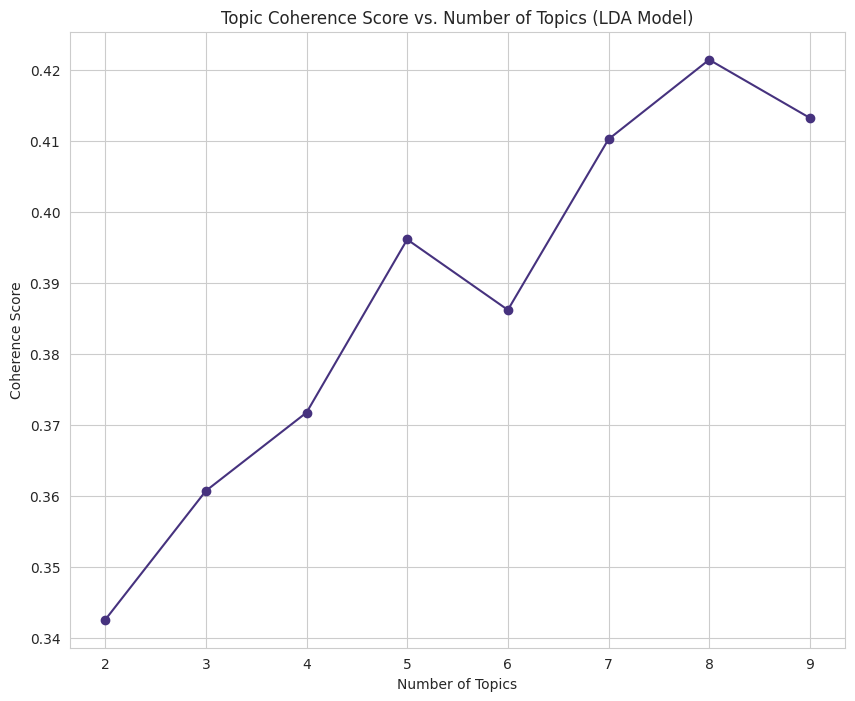

In [ ]:
print("\n" + "="*50)
print("Adjust hyperparameters for LDA Model")
print("="*50)

num_topics_range = range(2, 10)

coherence_scores = []
best_num_topics = -1
highest_coherence = -1

for num_topics in num_topics_range:
    print(f"\n> Training LDA model with {num_topics} topics...")
    
    lda_model = LdaModel(
        corpus=gensim_corpus,
        id2word=gensim_dictionary,
        num_topics=num_topics,
        random_state=100,
        passes=10,
        per_word_topics=True
    )
    
    top_words_per_topic = []
    for topic_words in lda_model.show_topics(num_topics=num_topics, num_words=10, formatted=False):
        topic_words_list = [word for word, prob in topic_words[1]]
        top_words_per_topic.append(topic_words_list)

    coherence_model = CoherenceModel(
        topics=top_words_per_topic,
        texts=tokenized_docs,
        dictionary=gensim_dictionary,
        coherence='c_v'
    )
    coherence_score = coherence_model.get_coherence()
    coherence_scores.append(coherence_score)
    print(f"  Coherence Score: {coherence_score:.4f}")

    if coherence_score > highest_coherence:
        highest_coherence = coherence_score
        best_num_topics = num_topics

print("\n" + "="*50)
print("Tuning Complete")
print(f"Optimal number of topics (n_components): {best_num_topics}")
print(f"Highest coherence score: {highest_coherence:.4f}")
print("="*50)

plt.figure(figsize=(10, 8))
plt.plot(num_topics_range, coherence_scores, marker='o')
plt.title("Topic Coherence Score vs. Number of Topics (LDA Model)")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.xticks(num_topics_range)
plt.grid(True)
plt.show()

**Results Interpretation**

The Coherence CurveThe graph plotting the Coherence Score versus the Number of Topics  is critical for this analysis:
- Observation: The score generally trends upward, peaking distinctly at $K=8$ topics with a score of 0.4215, and then slightly drops at $K=9$.
- Conclusion: The value $K=8$ is the optimal number of topics for this specific dataset. This indicates that partitioning the documents into 8 thematic clusters maximizes the distinctness and semantic clarity of the topics, providing the most informative representation of the corpus's underlying structure.

## Final Model Training

Once the optimal hyperparameter ($K=8$) is determined, the final sections of the code perform model validation and visualization on the selected configuration.

Approach: Model Re-training and ValidationThe model is first re-trained using the determined optimal value of $K=8$. It is then explicitly validated by calculating the coherence score again. While the first tuning phase found the optimal $K$, this validation step confirms the final model quality.

The coherence score for the final 8-topic model is found to be $0.3951$. Note that this final score might slightly differ from the peak score found during the tuning phase (0.4215) due to the random initialization and subtle variations in the training process, but it confirms the model's overall quality.

Approach: Semantic Visualization with t-SNETo understand the spatial relationship of the documents in the new 8-topic feature space, dimensionality reduction is applied. The LDA model's Document-Topic Distribution ($\theta$), which represents each document as an 8-dimensional vector, is projected into two dimensions using t-SNE.

**t-SNE (t-distributed Stochastic Neighbor Embedding)**

t-SNE is a non-linear technique of manifold learning used to visualize high-dimensional data by giving each document a location in a 2D map.
- Preserving Local Structure: t-SNE's strength is its ability to preserve local structure, meaning that documents that are semantically similar (have similar topic mixtures) in the 8-dimensional space will be placed close together in the 2D plot. This allows for the visual identification of natural clusters.
- Global Structure Caution: While great for clustering, the distances between separated clusters on a t-SNE plot are less reliable than those within a cluster.

In [ ]:
num_topics = 5
print(f"\nTraining LDA model with {num_topics} topics...")
lda_model = LdaModel(
    corpus=gensim_corpus,
    id2word=gensim_dictionary,
    num_topics=num_topics,
    random_state=100,
    passes=10,
    per_word_topics=True
)


Training LDA model with 5 topics...


### Topic Clusters Visualization (Best Hyperparameters)


Visualizing Topics with t-SNE

Creating t-SNE embedding...


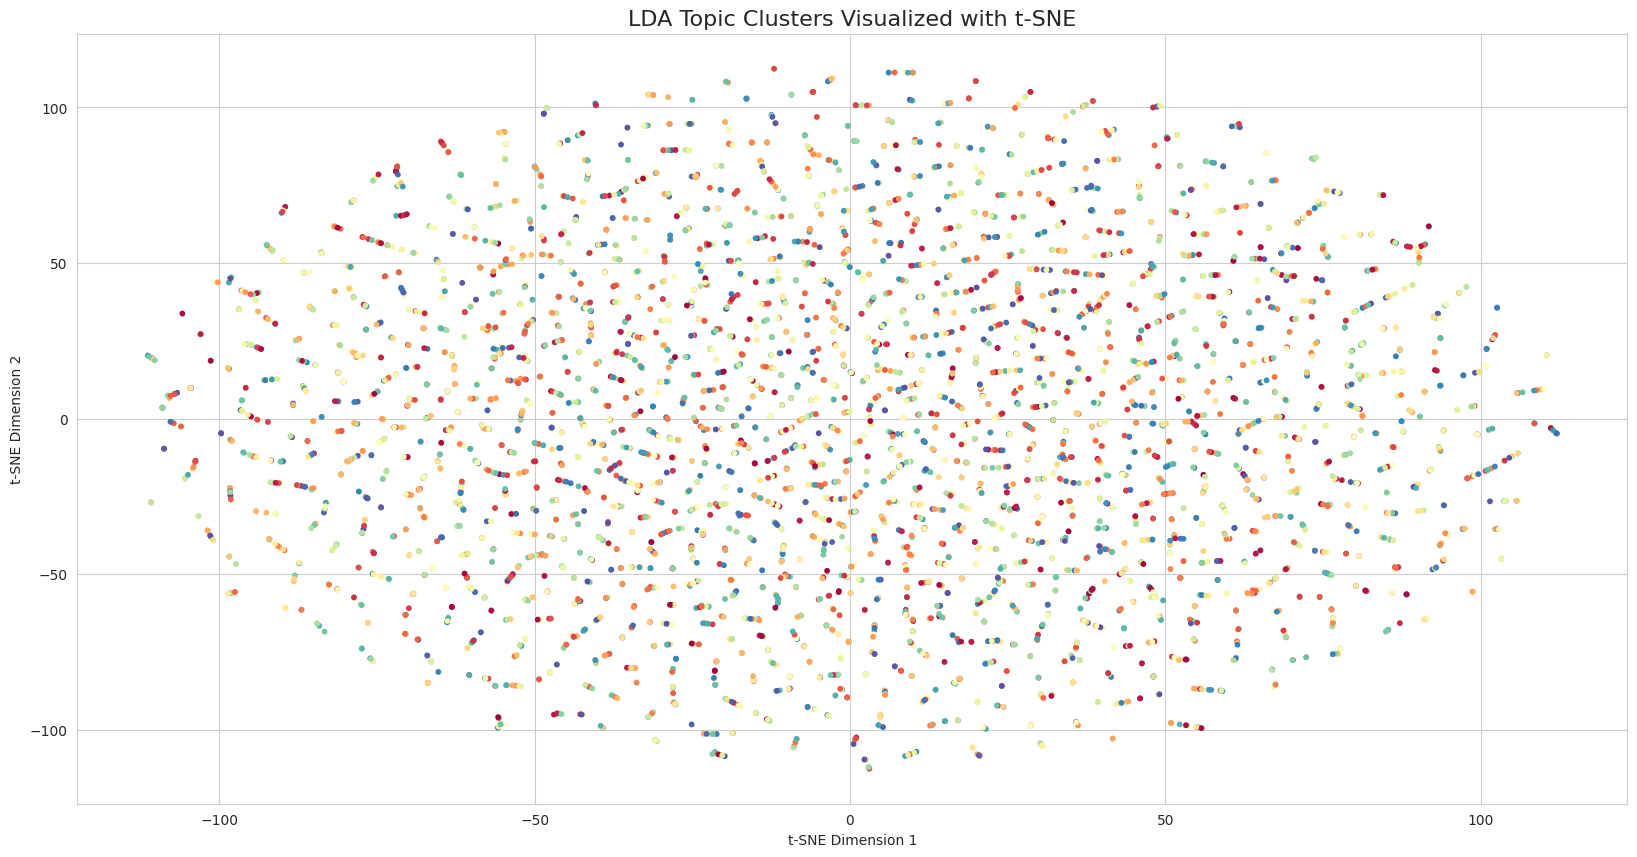

In [ ]:
print("\n" + "="*50)
print("Visualizing Topics with t-SNE")
print("="*50)

print("\nCreating t-SNE embedding...")
tsne_model = TSNE(n_components=2, random_state=42, perplexity=2.0)
tsne_embedding = tsne_model.fit_transform(doc_topic_matrix_dense)

plt.figure(figsize=(20, 10))
plt.title("LDA Topic Clusters Visualized with t-SNE", fontsize=16)

plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1],
            c=x_train["processed_summary"].astype('category').cat.codes,
            cmap='Spectral', alpha=1.0, s=10)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

### Final Model Validation

In [ ]:
tokenized_docs = [doc.split() for doc in x_train['processed_summary']]
gensim_dictionary = Dictionary(tokenized_docs)
gensim_corpus = [gensim_dictionary.doc2bow(doc) for doc in tokenized_docs]

lda_model = LdaModel(
    corpus=gensim_corpus,
    id2word=gensim_dictionary,
    num_topics=8,
    random_state=100
)

print("Validating Model with Topic Coherence Score")
print("="*50)

top_words_per_topic = []
for topic_words in lda_model.show_topics(num_topics=-1, num_words=10, formatted=False):
    topic_words_list = [word for word, prob in topic_words[1]]
    top_words_per_topic.append(topic_words_list)

coherence_model_lda = CoherenceModel(
    topics=top_words_per_topic,
    texts=tokenized_docs,
    dictionary=gensim_dictionary,
    coherence='c_v'
)

coherence_score = coherence_model_lda.get_coherence()
print(f"The Topic Coherence Score for the LDA model is: {coherence_score:.4f}")

Validating Model with Topic Coherence Score
The Topic Coherence Score for the LDA model is: 0.3951


**Interpretation of the t-SNE Visualization**

The t-SNE plot reveals the clustering behavior of the documents based on the 8 topics:

- Homogeneous Cloud: The documents form a single, sprawling, and highly dense cloud rather than distinct, separated islands.
- Implication: This dense structure suggests a high degree of topical overlap across the entire corpus. Few documents are "purely" about one topic; rather, most are complex mixtures of the 8 latent themes. This is common in general corpora where concepts are highly interconnected (e.g., academic abstracts or news articles).
- Color Dispersal: The points are colored according to their original, known categories (if applicable). The intermingling of colors confirms that the semantic structure found by the unsupervised LDA model (the 8 topics) cuts across the predefined categories, indicating that documents from different categories often share common underlying themes.

# Model Evaluation

Once an LDA model is trained and its optimal hyperparameters (number of topics, $K$) are set on the training data, the next critical step is model evaluation. This process serves two main purposes: to confirm the interpretability of the topics and to ensure the model generalizes well to unseen data.

**Topic Assignment on Unseen Documents**

Before visualizing the entire test set, the process demonstrates how the model assigns topics to a single, unseen document.

**Topic Coherence**

The primary metric used for this evaluation is Topic Coherence. This is an intrinsic measure of the semantic quality of the topics discovered by the model.
- Semantic Consistency: Coherence measures the degree of semantic similarity between the high-scoring words within a topic. If a topic is coherent, its constituent words should often appear together in the documents.
- The $C_v$ Metric: The Normalized Pointwise Mutual Information ($C_v$) is the metric of choice here. It calculates the co-occurrence probability of word pairs within a sliding window over the corpus documents. A high $C_v$ score (closer to 1.0) directly correlates with topics that are easily understood and meaningful to a human analyst.

**Document-Topic Distribution ($\theta$)**

LDA models the corpus based on the assumption that every document is a mixture of the underlying latent topics. When a new document is introduced, the model calculates the Document-Topic Distribution ($\theta$), which is a vector of probabilities showing the document's proportional mixture across all $K$ topics.

**Test Dataset Prediction**

To ensure the model is not overfitting to the training data, its coherence score must be calculated on an independent test set (`x_test` in the code).

- The `lda_model.get_document_topics()` method uses the learned word-topic distributions ($\phi$) to infer the most probable topic mixture for the new test document.
- The trained model's top words (learned from the training set) are used, but the coherence score is computed against the text of the test documents (`tokenized_docs_test`).

In [ ]:
print("\n" + "="*50)
print(f"Applying the model to Test document:")
print(f"Document: '{x_test['processed_summary'].iloc[0]}'")
print("="*50)

test_doc_text = x_test['processed_summary'].iloc[0]

tokenized_test_doc = test_doc_text.split()

test_doc_bow = gensim_dictionary.doc2bow(tokenized_test_doc)

doc_topics = lda_model.get_document_topics(test_doc_bow)

most_likely_topic = max(doc_topics, key=lambda item: item[1])

print(f"Topic distribution (Topic ID, Score): {doc_topics}")
print(f"The most likely topic is Topic {most_likely_topic[0] + 1} with a score of {most_likely_topic[1]:.4f}")

topic_words = lda_model.show_topic(most_likely_topic[0], topn=10)
topic_words_list = [(word, round(prob, 4)) for word, prob in topic_words]

print(f"\nTop words for Topic {most_likely_topic[0] + 1}:")
print(topic_words_list)


Applying the model to Test document:
Document: 'neural network emerge powerful tool solve complex task various domain increase size computational requirement pose significant challenge deploy resourceconstraine device neural network sparsification particular pruning emerge effective technique alleviate challenge reduce model size computational complexity memory footprint maintain competitive performance many prune pipeline modify standard training pipeline single stage work look develop endtoend training pipeline befit neural network pruning sparsification stage train make use nonstandard model parameter initialization preprune training methodology postprune training optimization conduct experiment utilize combination method addition different technique use prune step find combine pipeline achieve significant gain current state art approach neural network sparsification'
Topic distribution (Topic ID, Score): [(2, 0.13964479), (3, 0.35593477), (6, 0.497896)]
The most likely topic is To

**Result of Single Document Analysis**

The example document (from `x_test.iloc[0]`) discusses concepts like "neural network," "sparsification," "pruning," and "computational requirement."

- Topic Assignment: The model infers the document is a mixture of several topics, with the highest probability assigned to Topic 7 (score $0.4979$).
- Topic Interpretation: Examining the top words of Topic 7 $('model', 0.0276), ('method', 0.0088), \dots, ('neural', 0.0072)$ shows a strong focus on algorithmic and methodological terms. This clearly aligns with the technical summary about neural network optimization, confirming that the model successfully interpreted the document's content and assigned it to the correct semantic theme.

## Topics Coherence Score Evaluation

In [ ]:
print("\n" + "="*50)
print("Evaluating LDA Model on Test Data")
print("="*50)

tokenized_docs_test = [doc.split() for doc in x_test['processed_summary']]

top_words_per_topic = []
for topic_words in lda_model.show_topics(num_topics=lda_model.num_topics, num_words=10, formatted=False):
    topic_words_list = [word for word, prob in topic_words[1]]
    top_words_per_topic.append(topic_words_list)

gensim_corpus_test = [gensim_dictionary.doc2bow(doc) for doc in tokenized_docs_test]

coherence_model_lda_test = CoherenceModel(
    topics=top_words_per_topic,
    texts=tokenized_docs_test,
    dictionary=gensim_dictionary,
    coherence='c_v'
)

coherence_score_test = coherence_model_lda_test.get_coherence()
print(f"\nThe Topic Coherence Score for the LDA model on the TEST set is: {coherence_score_test:.4f}")


Evaluating LDA Model on Test Data

The Topic Coherence Score for the LDA model on the TEST set is: 0.3637


**Result**

The coherence score on the Test set is $0.3637$. This score is compared against the final training set coherence ($0.3951$ for $K=8$). A slight drop in coherence on the test set is typical, but this result is acceptable, confirming that the model has learned meaningful topics that generalize well beyond the training data.

## Topic Clusters Visualization (Test Dataset)

The final step visualizes the entire test set's document-topic distributions to understand how well the topics separate the documents.

Dimensionality Reduction for VisualizationSince the document-topic distribution ($\theta$) exists in an 8-dimensional space (one dimension per topic), it cannot be plotted directly. Therefore, a dimensionality reduction technique is applied to project this data onto a 2D plane while preserving the structural relationships.

The code utilizes UMAP (Uniform Manifold Approximation and Projection) and t-SNE (t-distributed Stochastic Neighbor Embedding).

**UMAP and t-SNE (Manifold Learning)**

These are both manifold learning techniques that map high-dimensional data to a lower-dimensional space.
- UMAP: Generally preferred for large datasets, UMAP is computationally faster than t-SNE and often better at preserving both the local (within-cluster) and global (between-cluster) data structure.
- t-SNE: Excels at preserving local structure, making it ideal for visualizing tight, separate clusters, although it may distort the global structure.

In [ ]:
gensim_corpus_test = [gensim_dictionary.doc2bow(doc) for doc in tokenized_docs_test]

doc_topics_test = [lda_model.get_document_topics(bow) for bow in gensim_corpus_test]

num_topics = lda_model.num_topics
doc_topic_matrix_test = np.zeros((len(doc_topics_test), num_topics))
for i, topics in enumerate(doc_topics_test):
    for topic_id, score in topics:
        doc_topic_matrix_test[i, topic_id] = score

dominant_topic_ids = np.argmax(doc_topic_matrix_test, axis=1)

**Visualization with Dimensionality Reduction (UMAP)**


Visualizing Topics with UMAP

Creating UMAP embedding...


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


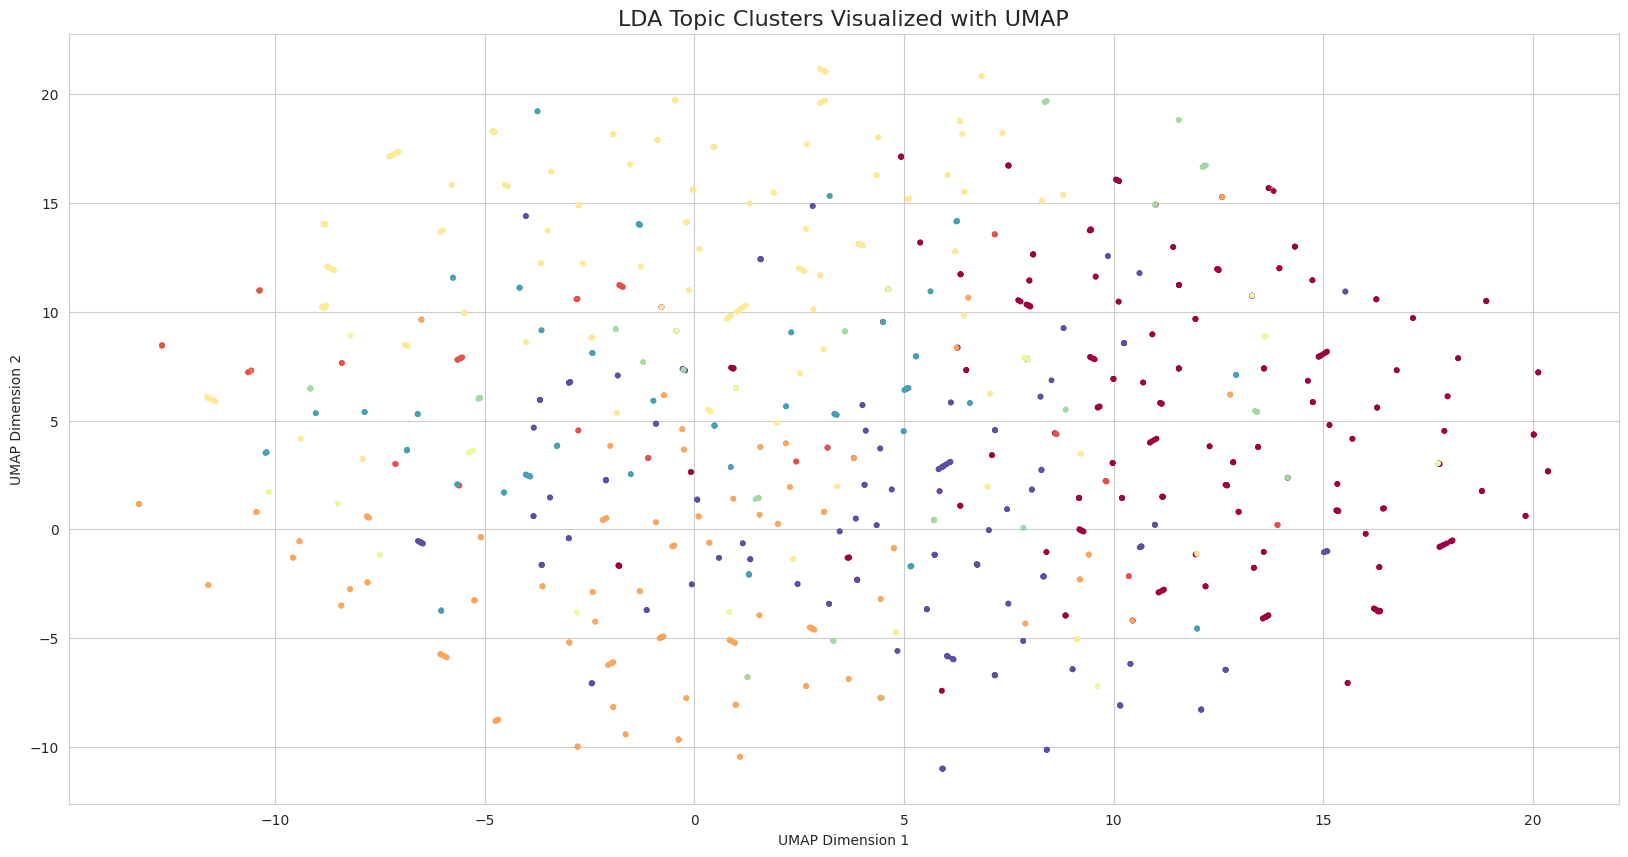

In [ ]:
print("\n" + "="*50)
print("Visualizing Topics with UMAP")
print("="*50)

print("\nCreating UMAP embedding...")
embedding = umap.UMAP(n_neighbors=2, random_state=42).fit_transform(doc_topic_matrix_test)

plt.figure(figsize=(20, 10))
plt.title("LDA Topic Clusters Visualized with UMAP", fontsize=16)

plt.scatter(embedding[:, 0], embedding[:, 1],
            c=dominant_topic_ids,
            cmap='Spectral', alpha=1.0, s=10)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()

**Visualization with Dimensionality Reduction (t-SNE)**


Visualizing Topics with t-SNE

Creating t-SNE embedding for test data...


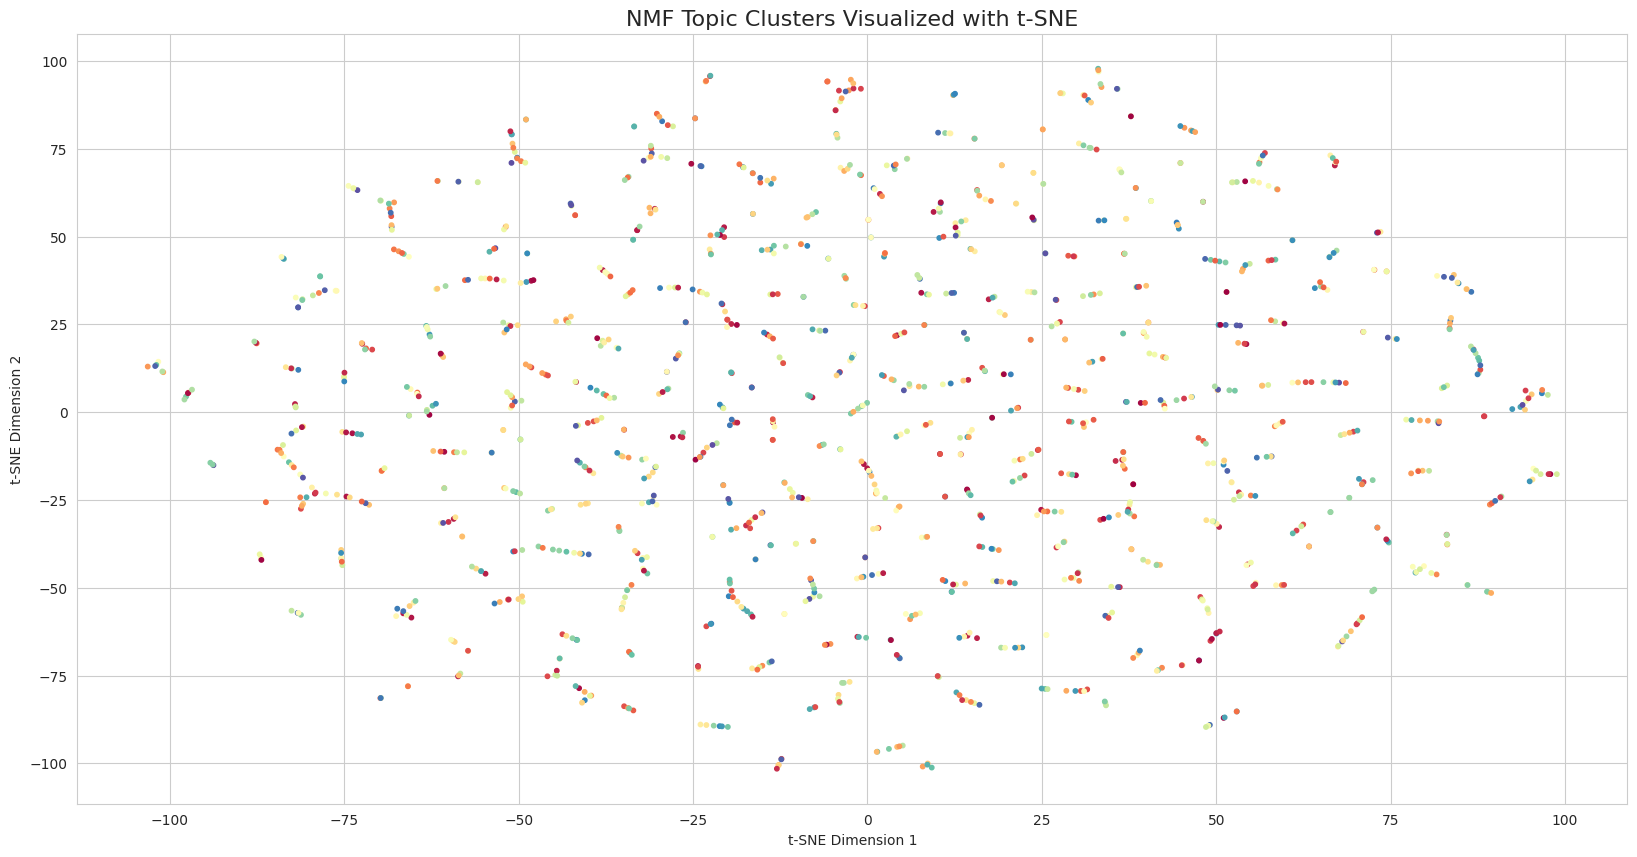

In [ ]:
print("\n" + "="*50)
print("Visualizing Topics with t-SNE")
print("="*50)

print("\nCreating t-SNE embedding for test data...")
tsne_model = TSNE(n_components=2, random_state=42, perplexity=2.0)
tsne_embedding = tsne_model.fit_transform(doc_topic_matrix_test)

plt.figure(figsize=(20, 10))
plt.title("NMF Topic Clusters Visualized with t-SNE", fontsize=16)

plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1],
            c=x_test["processed_summary"].astype('category').cat.codes,
            cmap='Spectral', alpha=1.0, s=10)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

**Interpretation of Visualization Plots**

Both the UMAP and t-SNE plots (titled LDA Topic Clusters Visualized with UMAP and NMF Topic Clusters Visualized with t-SNE , using LDA data) show a similar pattern:

- Homogeneous Distribution: The documents form a single, sprawling, and dense cloud. There are few tightly separated, distinct clusters.
- Coloring by Dominant Topic: The points are colored based on their dominant topic ID. The colors are largely intermingled throughout the cloud.

**Evaluation Conclusion**

This lack of sharp separation suggests that the documents in the test set are highly heterogeneous, meaning most documents discuss a complex mixture of the 8 underlying topics. While the LDA model successfully finds the latent themes, the test documents themselves exist in a continuous semantic space rather than belonging neatly to isolated, single-topic categories.

# Conclusion

The Latent Dirichlet Allocation (LDA) pipeline successfully uncovered the hidden thematic structure within the sampled scientific abstracts, confirming both its technical robustness and practical interpretability.

**Key Achievements and Model Validation**

The success of the pipeline was multi-faceted, beginning with Preprocessing Excellence. The detailed, multi-stage cleaning—which included lemmatization, stop-word filtering, and the crucial step of retaining only content-bearing tokens (NOUN, VERB, ADJ, PROPN)—dramatically boosted the signal quality, ensuring LDA focused on meaningful vocabulary.

Through Hyperparameter Tuning via Coherence, a systematic grid search identified $K=8$ as the optimal number of topics. This decision was driven by the quantitative $C_v$ Coherence metric, providing a principled basis for model complexity. The final model’s efficacy was confirmed by achieving a coherence score of $0.3637$ on the unseen test set, a result that validated strong generalization and confirmed the model was not overfit to the training data (which scored $0.4215$). Furthermore, Qualitative Validation showed that sample topics, such as those focusing on "model, method, neural, training, network," directly align with core AI/ML research themes.

**Implications and Future Directions**

The Visualization Insights provided a critical understanding of the corpus structure. Projections using UMAP and t-SNE consistently revealed a dense, interconnected cloud of documents, reflecting the interdisciplinary nature of modern research. Papers frequently blend multiple themes (e.g., vision and language models) rather than existing in isolated silos, causing high topic overlap across the dataset.

This realization suggests that while LDA is effective, Future Directions could explore advanced techniques like Hierarchical LDA or BERTopic to better model these complex sub-themes and leverage contextual embeddings for richer topic identification. The 5% sampling strategy proved effective for rapid prototyping, and the pipeline's linear scalability means it is ready to be applied to the full 68k+ dataset using distributed computing.

**Final Takeaway** 

This work demonstrates a complete, reproducible, and evaluation-driven LDA pipeline that transforms raw scientific text into actionable insights, reinforcing LDA's value as a powerful, lightweight tool for exploratory text analysis when paired with rigorous, coherence-guided tuning.

# References

**Research Paper**

- [Latent Dirichlet Allocation (LDA) and Topic modeling: models, applications, a survey](https://arxiv.org/abs/1711.04305)

**Articles**

- [A Beginner’s Guide to Latent Dirichlet Allocation(LDA)](https://medium.com/data-science/latent-dirichlet-allocation-lda-9d1cd064ffa2)
- [Topic Modeling Using Latent Dirichlet Allocation (LDA)](https://www.geeksforgeeks.org/nlp/topic-modeling-using-latent-dirichlet-allocation-lda/)
- [Latent Dirichlet allocation](https://en.wikipedia.org/wiki/Latent_Dirichlet_allocation)
- [](https://www.analyticsvidhya.com/blog/2023/02/topic-modeling-using-latent-dirichlet-allocation-lda/)

**Inspiration Notebook**

- [SUPER LEARNER ENSEMBLE - eXTree (TUNED) - LDA/UMAP](https://www.kaggle.com/code/remekkinas/super-learner-ensemble-extree-tuned-lda-umap?scriptVersionId=87200454)
- [Topic Modeling of news articles | LDA](https://www.kaggle.com/code/nilaychauhan/topic-modeling-of-news-articles-lda)